# ch287 — Information Theory

*(Uses logarithms from ch043; probability distributions from ch248; connects directly to ML loss functions)*

## 1. The Central Question

How do you measure the amount of information in a message?

Claude Shannon (1948) answered this by connecting information to surprise. A rare event carries more information than a common one. If a fair coin lands heads, you learn 1 bit. If a 1-in-a-million event occurs, you learn ~20 bits.

The **self-information** (surprisal) of event $x$ with probability $p$:
$$I(x) = -\log_2 p(x) \quad \text{(bits)}$$

Or in nats (natural units, used in ML):
$$I(x) = -\ln p(x)$$

---

## 2. Why This Definition?

Three axioms uniquely determine this form:
1. $I(p)$ is a continuous, decreasing function of $p$
2. $I(1) = 0$ — certain events carry no information
3. $I(p_1 \cdot p_2) = I(p_1) + I(p_2)$ — independent events add information

The only function satisfying all three: $I(p) = -\log p$.

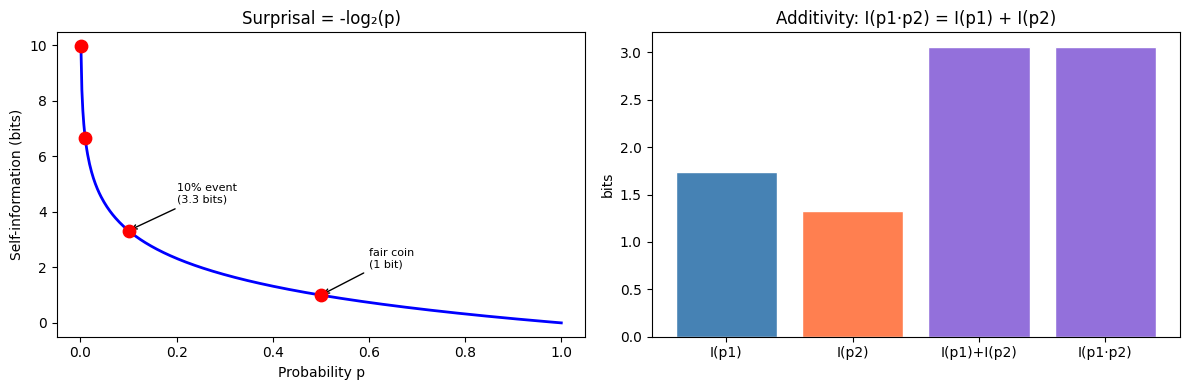

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def self_information(p: float | np.ndarray, base: str = 'nats') -> float | np.ndarray:
    """Surprisal: -log(p). base='bits' uses log2, 'nats' uses ln."""
    if base == 'bits':
        return -np.log2(np.clip(p, 1e-15, 1.0))
    return -np.log(np.clip(p, 1e-15, 1.0))

p_vals = np.linspace(0.001, 1.0, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(p_vals, self_information(p_vals, 'bits'), 'b-', lw=2)
ax1.scatter([0.5, 0.1, 0.01, 0.001],
            self_information(np.array([0.5, 0.1, 0.01, 0.001]), 'bits'),
            s=80, color='red', zorder=5)
for p, label in [(0.5, 'fair coin\n(1 bit)'),
                  (0.1, '10% event\n(3.3 bits)')]:
    ax1.annotate(label, xy=(p, self_information(p, 'bits')),
                 xytext=(p+0.1, self_information(p, 'bits')+1), fontsize=8,
                 arrowprops=dict(arrowstyle='->', lw=1))
ax1.set_xlabel('Probability p'); ax1.set_ylabel('Self-information (bits)')
ax1.set_title('Surprisal = -log₂(p)')

# Verify additivity for independent events
p1, p2 = 0.3, 0.4
ax2.bar(['I(p1)', 'I(p2)', 'I(p1)+I(p2)', 'I(p1·p2)'],
        [self_information(p1, 'bits'),
         self_information(p2, 'bits'),
         self_information(p1, 'bits') + self_information(p2, 'bits'),
         self_information(p1*p2, 'bits')],
        color=['steelblue','coral','mediumpurple','mediumpurple'],
        edgecolor='white')
ax2.set_title('Additivity: I(p1·p2) = I(p1) + I(p2)')
ax2.set_ylabel('bits')

plt.tight_layout()
plt.show()

## 3. Cross-Entropy — The ML Loss Function

Cross-entropy measures the average number of bits needed to encode events from distribution $P$ using a code designed for distribution $Q$:

$$H(P, Q) = -\sum_x P(x) \log Q(x)$$

In classification, $P$ = true labels (one-hot), $Q$ = model predictions. Minimizing cross-entropy is identical to maximum likelihood estimation.

True class: [1, 0, 0]
Prediction                         CE loss
--------------------------------------------
Confident correct                   0.1054
Uncertain correct                   0.6931
Uniform (max entropy)               1.1087
Uncertain wrong                     2.3026
Confident wrong                     4.6052



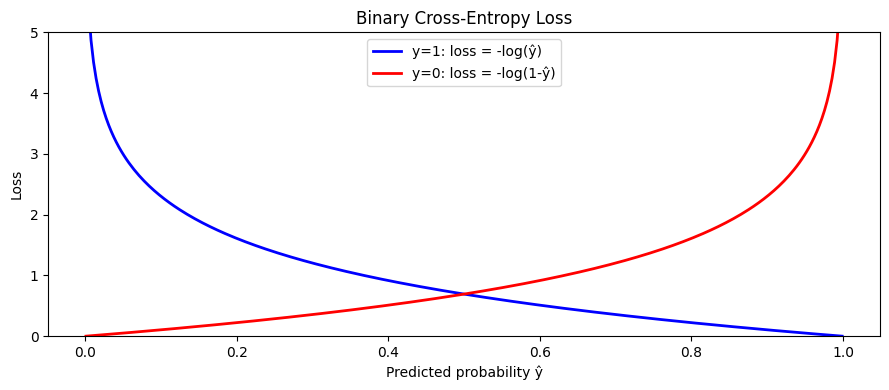

In [2]:
def cross_entropy(
    p_true: np.ndarray,
    q_pred: np.ndarray,
    eps: float = 1e-15,
) -> float:
    """Cross-entropy H(P, Q) in nats. p_true and q_pred are 1D probability vectors."""
    return -np.sum(p_true * np.log(np.clip(q_pred, eps, 1.0)))

def binary_cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Binary cross-entropy per sample, averaged."""
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Effect of prediction confidence on CE loss
y_true_probs  = np.array([1.0, 0.0, 0.0])  # true class = 0

predictions = [
    (np.array([0.9,  0.05, 0.05]), 'Confident correct'),
    (np.array([0.5,  0.3,  0.2]),  'Uncertain correct'),
    (np.array([0.33, 0.34, 0.33]), 'Uniform (max entropy)'),
    (np.array([0.1,  0.5,  0.4]),  'Uncertain wrong'),
    (np.array([0.01, 0.9,  0.09]), 'Confident wrong'),
]

print(f"True class: [1, 0, 0]")
print(f"{'Prediction':<30}  {'CE loss':>10}")
print("-" * 44)
for q, label in predictions:
    ce = cross_entropy(y_true_probs, q)
    print(f"{label:<30}  {ce:>10.4f}")

print()
# Binary CE curve
y_pred_range = np.linspace(0.001, 0.999, 300)
ce_true_1 = -np.log(y_pred_range)       # y=1: loss = -log(p)
ce_true_0 = -np.log(1 - y_pred_range)   # y=0: loss = -log(1-p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(y_pred_range, ce_true_1, 'b-', lw=2, label='y=1: loss = -log(ŷ)')
ax.plot(y_pred_range, ce_true_0, 'r-', lw=2, label='y=0: loss = -log(1-ŷ)')
ax.set_xlabel('Predicted probability ŷ')
ax.set_ylabel('Loss')
ax.set_ylim(0, 5)
ax.set_title('Binary Cross-Entropy Loss')
ax.legend()
plt.tight_layout()
plt.show()

## 4. What Comes Next

Cross-entropy decomposes into entropy plus KL divergence: $H(P,Q) = H(P) + D_{KL}(P \| Q)$. **ch288 — Entropy** develops the entropy term; **ch289 — KL Divergence** develops the divergence term. Understanding both is necessary to interpret what a neural network's loss function is actually minimizing.